# ZMUM - Projekt 2

**Autorzy:**
- Michał Cichocki
- Szymon Czajkowski

**Grupa:** DS1, Informatyka Data Science, 2 semestr


# Dataset: Free Spoken Digit Dataset

Free spoken digit dataset to zbiór nagrań wypowiadanych cyfr od 0 do 9, nagrywanych przez różnych mówców. Zbiór zawiera 3000 nagrań w formacie WAV, każde o długości około 1 lub 2 sekundy i częstotliwości próbkowania 8 kHz. Nagrania zostały wykonane przez 6 różnych mówców (3 mężczyzn i 3 kobiety) w kontrolowanym środowisku, co zapewnia dobrą jakość dźwięku bez szumów tła.

**Metody ekstrakcji cech:**
1. MFFC
2. Ręczna ekstrakcja cech
3. PCA

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import kagglehub
from collections import Counter
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.model_selection import GroupShuffleSplit

from scipy.signal import butter, filtfilt
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

RANDOM_STATE = 123
np.random.seed(RANDOM_STATE)

/home/szymon/studia/zmum/zmum_project2/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Ładowanie danych
Pobieranie zbioru danych i ładowanie plików audio.
Parsujemy nazwę pliku, aby wyodrębnić etykietę oraz unikalnych mówców.
Każdy mówca odpowiada 500 próbkom w zbiorze (50 próbek na cyfrę, dla każdego mówcy).

In [2]:
path = kagglehub.dataset_download("joserzapata/free-spoken-digit-dataset-fsdd")
recordings_path = os.path.join(path, "recordings")

files = glob.glob(os.path.join(recordings_path, "*.wav"))

data = []
labels = []
speakers = []
max_len = 0
max_len_in_seconds = 0

for f in files:
    filename = os.path.basename(f)
    splited_filename = filename.split('_') 
    speaker = filename.split('_')[1]
    digit = int(splited_filename[0])

    y, sr = librosa.load(f, sr=None)
    
    data.append(y)
    labels.append(digit)
    speakers.append(speaker)

    if len(y) > max_len:
        max_len = len(y)

    max_len_in_seconds = max_len / sr

print(f"Loaded {len(data)} files.")
print(f"Maximum audio length: {max_len} samples and {max_len_in_seconds:.2f} seconds.")

Loaded 3000 files.
Maximum audio length: 18262 samples and 2.28 seconds.


In [3]:
label_counts = Counter(labels)
speaker_counts = Counter(speakers)

for digit in sorted(label_counts):
    print(f"Digit {digit}: {label_counts[digit]} samples")

print()

for speaker in sorted(speaker_counts):
    print(f"Speaker {speaker}: {speaker_counts[speaker]} samples")

Digit 0: 300 samples
Digit 1: 300 samples
Digit 2: 300 samples
Digit 3: 300 samples
Digit 4: 300 samples
Digit 5: 300 samples
Digit 6: 300 samples
Digit 7: 300 samples
Digit 8: 300 samples
Digit 9: 300 samples

Speaker george: 500 samples
Speaker jackson: 500 samples
Speaker lucas: 500 samples
Speaker nicolas: 500 samples
Speaker theo: 500 samples
Speaker yweweler: 500 samples


## Analiza i preprocessing danych

Wykres przedstawia próbkę audio dla cyfry '4' wypowiedzianą przez jednego z mówców.

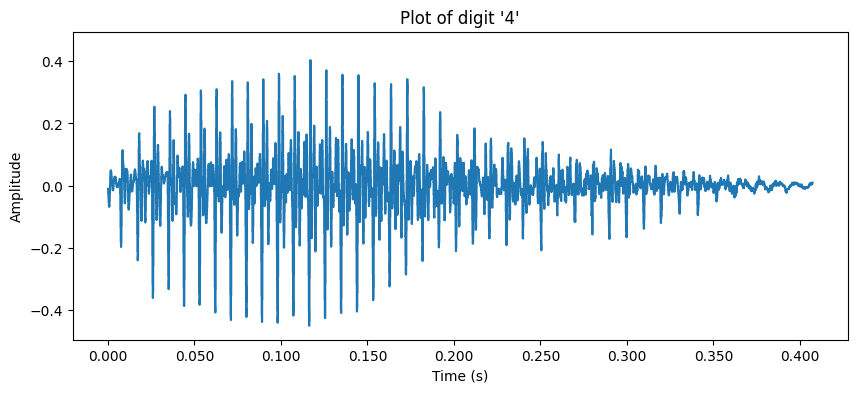

In [4]:
plt.figure(figsize=(10, 4))
librosa.display.waveshow(data[0], sr=8000)
plt.title(f"Plot of digit '{labels[0]}'")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

Przykład prostego preprocessingu sygnału audio z wykorzystaniem filtrów górnoprzepustowych i dolnoprzepustowych.


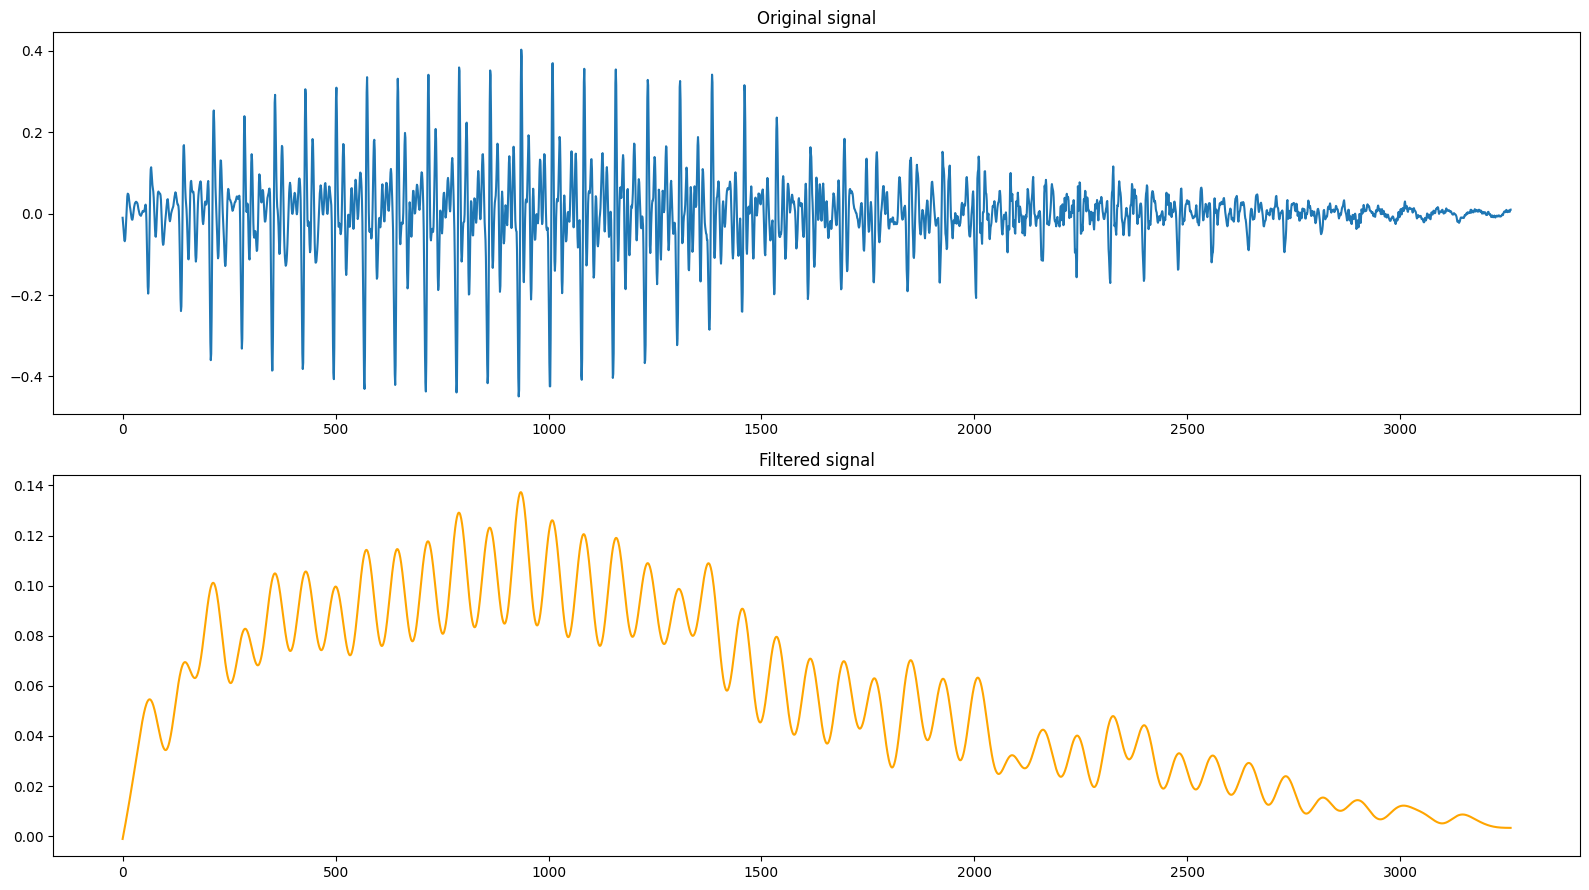

In [5]:
def apply_butter_filter(data, cutoff, fs, filter_type, order=5):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype=filter_type, analog=False)
    return filtfilt(b, a, data)

clean_signal = apply_butter_filter(data[0], 30, 8000, 'high')

rectified_signal = np.abs(clean_signal)

final_envelope = apply_butter_filter(rectified_signal, 100, 8000, 'low')

fig, axs = plt.subplots(2, 1, figsize=(16, 9))

axs[0].plot(data[0])
axs[0].set_title("Original signal")

axs[1].plot(final_envelope, color='orange')
axs[1].set_title("Filtered signal")

plt.tight_layout()
plt.show()

# Odtwarzanie dźwięku przed i po preprocessingu

In [6]:
from IPython.display import Audio, display

display(Audio(data[0], rate=8000))

In [7]:
from IPython.display import Audio, display

display(Audio(final_envelope, rate=8000))

Używany zbiór danych z racji tego, że przygotowany jest specjalnie pod rozwiązania z uczeniem maszynowym nie wymaga rozbudowanego procesu preprocessingu, próbki są czyste bez szumów i są gotowe do podania ich na wejście modelu. 

## Metoda ekstrakcji cech 1: MFCC
Wykorzystanie 13 współczynników MFCC do ekstrakcji cech z sygnału audio. Dla każdego współczynnika obliczane są średnia i odchylenie standardowe, tworząc wektor cech o długości 26 dla każdej próbki audio.

In [8]:
def extract_features_mfcc(audio_data, sr=8000, n_mfcc=13):
    features = []
    for y in audio_data:
        n_fft = 256
        if len(y) < n_fft:
            y = librosa.util.fix_length(y, size=n_fft)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc, n_fft=n_fft)

        mean = np.mean(mfcc, axis=1)
        std = np.std(mfcc, axis=1)
        feature_vector = np.concatenate((mean, std))
        features.append(feature_vector)
    return np.array(features)

In [9]:
X_mfcc = extract_features_mfcc(data)
y_labels = np.array(labels)
print(f"X_mfcc shape: {X_mfcc.shape}")

X_mfcc shape: (3000, 26)


In [10]:
pd.DataFrame(X_mfcc).describe()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,...,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,-521.950684,60.736946,19.041374,6.729394,-18.469208,-11.285451,-14.729140,-8.470333,-12.341199,-4.742513,...,21.179005,19.405762,14.975987,14.139935,11.853830,10.722294,10.385368,9.540370,9.101237,9.167762
std,97.306183,33.625366,22.411167,18.013348,15.150355,15.265455,10.952209,12.597729,10.370655,7.033990,...,9.007202,6.080818,5.730051,4.921770,4.109142,3.607253,3.392964,3.188810,3.059760,3.174673
min,-768.909851,-29.934601,-46.618084,-71.252647,-74.340439,-64.652267,-55.042404,-44.888573,-51.924110,-32.089977,...,1.424096,0.858621,2.577745,1.293352,0.882006,1.097681,0.617957,0.614436,0.772170,0.997481
25%,-620.894226,37.488009,5.037143,-4.014527,-29.027328,-21.518225,-21.573213,-17.860568,-17.475667,-9.035496,...,14.451722,15.116392,10.935400,10.577346,9.063699,8.198569,8.029344,7.279973,6.993518,6.921003
50%,-496.982864,59.804127,18.707217,7.811389,-19.301566,-10.912374,-14.562087,-8.754145,-10.579700,-4.233373,...,20.552443,19.255187,14.157261,13.815739,11.450168,10.463655,10.249615,9.388502,8.938745,8.948737
75%,-438.048820,81.369934,33.820361,18.567421,-8.546514,-0.611611,-6.945333,1.391451,-5.166776,0.164964,...,27.101058,23.443194,18.379319,17.418047,14.225152,12.937384,12.603091,11.551111,10.883960,11.193202
max,-310.517487,193.115738,95.244759,64.474113,33.367538,30.265463,17.417435,25.988861,14.797962,16.840475,...,55.613590,43.131809,40.132236,32.909645,32.669197,25.408028,24.207558,22.575003,20.278944,23.061460


# Spektrogram dla MFCC

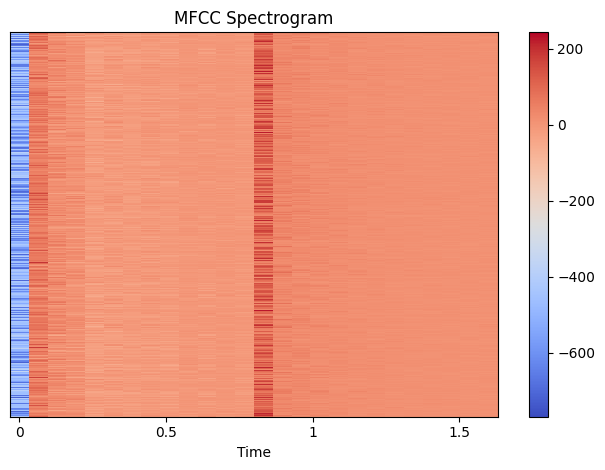

In [11]:
librosa.display.specshow(X_mfcc, sr=8000, x_axis='time')
plt.colorbar()
plt.title('MFCC Spectrogram')
plt.tight_layout()
plt.show()

## Metoda ekstrakcji cech 2: Ręczna ekstrakcja
Wykorzystano różne cechy sygnału audio takie jak Zero Crossing Rate, Spectral Rolloff, Spectral Centroid, Spectral Bandwidth, Spectral Contrast, Chroma STFT oraz Root Mean Square Energy z biblioteki `librosa` . Dla każdej z tych cech obliczana jest średnia wartość wzdłuż osi czasowej, a następnie wszystkie te wartości są łączone w jeden wektor cech dla każdej próbki audio.

In [12]:
def manual_features(signal, rate=8000, n_fft=2048):
    y = signal
    if len(y) < n_fft:
        y = librosa.util.fix_length(y, size=n_fft)

    zcr = librosa.feature.zero_crossing_rate(y=y)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=rate, n_fft=n_fft)
    spec_cent = librosa.feature.spectral_centroid(y=y, sr=rate, n_fft=n_fft)
    spec_bw = librosa.feature.spectral_bandwidth(y=y, sr=rate, n_fft=n_fft)
    spec_cont = librosa.feature.spectral_contrast(y=y, sr=rate, n_fft=n_fft, n_bands=4)
    chroma_stft = librosa.feature.chroma_stft(y=y, sr=rate, n_fft=n_fft)
    rmse = librosa.feature.rms(y=y, frame_length=n_fft)

    return np.concatenate((
        zcr.mean(axis=1),
        rolloff.mean(axis=1),
        spec_cent.mean(axis=1),
        spec_bw.mean(axis=1),
        spec_cont.mean(axis=1),
        chroma_stft.mean(axis=1),
        rmse.mean(axis=1)
    ))

In [13]:
X_manual = np.array([manual_features(y) for y in data])
print(f"X_manual shape: {X_manual.shape}")
pd.DataFrame(X_manual).describe()

/home/szymon/studia/zmum/zmum_project2/.venv/lib/python3.12/site-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


X_manual shape: (3000, 22)


,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,...,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,0.163221,2250.163343,1167.202689,966.633748,29.139386,18.899925,19.694146,17.529211,21.100417,0.317355,...,0.342328,0.370495,0.353744,0.337700,0.330117,0.359388,0.412960,0.449889,0.381021,0.039839
std,0.069416,576.315649,291.343862,159.479387,6.202872,4.155811,3.544965,2.830496,3.845933,0.195645,...,0.198074,0.206325,0.202196,0.198059,0.188232,0.182573,0.194508,0.203973,0.193308,0.027748
min,0.041406,863.281250,585.492046,396.452806,14.932829,9.269678,11.967976,9.128485,13.679153,0.008789,...,0.006014,0.006800,0.008845,0.012554,0.019025,0.015025,0.012113,0.010971,0.012964,0.001314
25%,0.112887,1829.124814,965.387180,856.824639,24.651741,15.440815,17.162877,15.365015,18.578318,0.154375,...,0.176606,0.200899,0.186364,0.167613,0.176150,0.214444,0.272866,0.302707,0.235668,0.011144
50%,0.147819,2265.625000,1111.491006,973.121463,27.687486,18.952558,19.291513,17.020645,20.578060,0.298578,...,0.318127,0.347022,0.328702,0.316491,0.307117,0.354577,0.406721,0.435740,0.365975,0.040503
75%,0.196309,2704.352679,1348.052035,1093.452118,33.265599,22.140534,21.974548,19.488738,23.013563,0.445719,...,0.483587,0.520488,0.498846,0.481850,0.460404,0.486299,0.548242,0.587719,0.506205,0.058241
max,0.451477,3475.260417,2226.571305,1369.924617,48.221590,31.880878,32.435038,29.263194,32.469208,1.000000,...,1.000000,1.000000,1.000000,0.981630,1.000000,0.998716,1.000000,1.000000,1.000000,0.145232


## Metoda ekstrakcji cech 3: PCA

Wykorzystanie analizy głównych składowych (PCA) do redukcji wymiarowości surowych danych audio. Najpierw dane audio są dopełniane zerami do maksymalnej długości, a następnie spłaszczane i normalizowane. PCA jest następnie stosowane do zredukowania wymiarowości do 50 głównych składowych.

In [14]:
X_audio_padded = np.array([librosa.util.fix_length(y, size=max_len) for y in data])
X_audio_flat = X_audio_padded.reshape(len(X_audio_padded), -1)
X_audio_flat = X_audio_flat / np.max(np.abs(X_audio_flat))

pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_audio_flat)

print(f"X_pca shape: {X_pca.shape}")
pd.DataFrame(X_manual).describe()

X_pca shape: (3000, 50)


,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,...,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,0.163221,2250.163343,1167.202689,966.633748,29.139386,18.899925,19.694146,17.529211,21.100417,0.317355,...,0.342328,0.370495,0.353744,0.337700,0.330117,0.359388,0.412960,0.449889,0.381021,0.039839
std,0.069416,576.315649,291.343862,159.479387,6.202872,4.155811,3.544965,2.830496,3.845933,0.195645,...,0.198074,0.206325,0.202196,0.198059,0.188232,0.182573,0.194508,0.203973,0.193308,0.027748
min,0.041406,863.281250,585.492046,396.452806,14.932829,9.269678,11.967976,9.128485,13.679153,0.008789,...,0.006014,0.006800,0.008845,0.012554,0.019025,0.015025,0.012113,0.010971,0.012964,0.001314
25%,0.112887,1829.124814,965.387180,856.824639,24.651741,15.440815,17.162877,15.365015,18.578318,0.154375,...,0.176606,0.200899,0.186364,0.167613,0.176150,0.214444,0.272866,0.302707,0.235668,0.011144
50%,0.147819,2265.625000,1111.491006,973.121463,27.687486,18.952558,19.291513,17.020645,20.578060,0.298578,...,0.318127,0.347022,0.328702,0.316491,0.307117,0.354577,0.406721,0.435740,0.365975,0.040503
75%,0.196309,2704.352679,1348.052035,1093.452118,33.265599,22.140534,21.974548,19.488738,23.013563,0.445719,...,0.483587,0.520488,0.498846,0.481850,0.460404,0.486299,0.548242,0.587719,0.506205,0.058241
max,0.451477,3475.260417,2226.571305,1369.924617,48.221590,31.880878,32.435038,29.263194,32.469208,1.000000,...,1.000000,1.000000,1.000000,0.981630,1.000000,0.998716,1.000000,1.000000,1.000000,0.145232


## Trenowanie modeli i porównanie

Zbiór dzielony jest na podzbiory treningowy i testowy ze zwróceniem uwagi na to aby żaden mówca nie znalazł się zarówno w zbiorze treningowym i testowym, taka sytuacja mogłaby doprowadzić do tego że model uczy się barwy głosu danego mówcy a nie rozpoznawać wypowiadane cyfry. Do ewaluacji będziemy wykorzystywać miary accuracy oraz f1-score. Modelami które zostaną przetestowane są:
- SVM
- RandomForest
- KNN
- LightGBM
- XGBoost

In [17]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

def train_and_evaluate(X, y, method_name):
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(X, y, groups=speakers))

    X_train = X[train_idx]
    y_train = y[train_idx]

    X_test = X[test_idx]
    y_test = y[test_idx]

    models = {
        "SVM": make_pipeline(StandardScaler(), SVC()),
        "RandomForest": RandomForestClassifier(random_state=42),
        "KNN": make_pipeline(StandardScaler(), KNeighborsClassifier()),
        "LightGBM": LGBMClassifier(random_state=42, verbosity=-1),
        "XGBoost": XGBClassifier(random_state=42),
    }

    results = []

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average="macro")
        conf_matrix = confusion_matrix(y_test, y_pred)
        results.append({"Dataset": method_name, "Model": name, "Accuracy": acc, "F1-Score": f1, "Conf_matrix": conf_matrix})
        print(f"{name} Accuracy: {acc:.4f}, F1-Score: {f1:.4f} for {method_name}")
    
    print()
    
    return results

In [18]:
results_mfcc = train_and_evaluate(X_mfcc, y_labels, "MFCC Features")
results_manual = train_and_evaluate(X_manual, y_labels, "Manual Features")
results_pca = train_and_evaluate(X_pca, y_labels, "PCA Features")

SVM Accuracy: 0.4620, F1-Score: 0.4567 for MFCC Features
RandomForest Accuracy: 0.5610, F1-Score: 0.5619 for MFCC Features
KNN Accuracy: 0.5210, F1-Score: 0.5054 for MFCC Features


/home/szymon/studia/zmum/zmum_project2/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM Accuracy: 0.5830, F1-Score: 0.5744 for MFCC Features
XGBoost Accuracy: 0.5240, F1-Score: 0.5152 for MFCC Features

SVM Accuracy: 0.2690, F1-Score: 0.2475 for Manual Features
RandomForest Accuracy: 0.2510, F1-Score: 0.2230 for Manual Features
KNN Accuracy: 0.2310, F1-Score: 0.2182 for Manual Features


/home/szymon/studia/zmum/zmum_project2/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM Accuracy: 0.3060, F1-Score: 0.2597 for Manual Features
XGBoost Accuracy: 0.2840, F1-Score: 0.2511 for Manual Features

SVM Accuracy: 0.1400, F1-Score: 0.0871 for PCA Features
RandomForest Accuracy: 0.1310, F1-Score: 0.1148 for PCA Features
KNN Accuracy: 0.1630, F1-Score: 0.1476 for PCA Features


/home/szymon/studia/zmum/zmum_project2/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM Accuracy: 0.1350, F1-Score: 0.1235 for PCA Features
XGBoost Accuracy: 0.1490, F1-Score: 0.1424 for PCA Features



In [22]:
all_results = results_mfcc + results_manual + results_pca
df_results = pd.DataFrame(all_results)
df_results

,Dataset,Model,Accuracy,F1-Score,Conf_matrix
0,MFCC Features,SVM,0.462,0.456718,"[[49, 1, 48, 2, 0, 0, 0, 0, 0, 0], [4, 66, 8, ..."
1,MFCC Features,RandomForest,0.561,0.561930,"[[51, 0, 15, 32, 0, 0, 2, 0, 0, 0], [9, 47, 3,..."
2,MFCC Features,KNN,0.521,0.505421,"[[66, 0, 28, 6, 0, 0, 0, 0, 0, 0], [36, 41, 1,..."
3,MFCC Features,LightGBM,0.583,0.574421,"[[51, 0, 37, 12, 0, 0, 0, 0, 0, 0], [9, 46, 6,..."
4,MFCC Features,XGBoost,0.524,0.515164,"[[51, 0, 35, 14, 0, 0, 0, 0, 0, 0], [17, 32, 3..."
5,Manual Features,SVM,0.269,0.247530,"[[15, 19, 41, 7, 2, 0, 0, 0, 0, 16], [16, 22, ..."
6,Manual Features,RandomForest,0.251,0.223014,"[[36, 13, 11, 6, 2, 0, 0, 0, 12, 20], [32, 6, ..."
7,Manual Features,KNN,0.231,0.218205,"[[21, 24, 34, 3, 3, 0, 0, 0, 0, 15], [48, 8, 2..."
8,Manual Features,LightGBM,0.306,0.259729,"[[43, 5, 5, 2, 2, 0, 0, 0, 22, 21], [36, 1, 6,..."
9,Manual Features,XGBoost,0.284,0.251115,"[[48, 4, 4, 3, 0, 0, 0, 0, 18, 23], [55, 0, 4,..."


Najlepsze wyniki były otrzymywane dla metody ekstrakcji MFCC. Najlepszym modelem w tym przypadku okazał się LightGBM. Otrzymane wyniki na domyślnych parametrach nie przekraczają wartości 0.6 dla metryki F1. Wynika to z trudności samej generalizacji wypowiadanych cyfr oraz małej ilości danych. Aktualnie modele uczą się na 4 mówcach, którzy mogą nie oddawać wszystkich sposobów mowy przez co model nie radzi sobie gdy dostaje próbki testowe wypowiadane przez innych mówców. Innym problemem jest wykorzystanie klasycznych modeli uczenia maszynowego, które mają ograniczone możliwości klasyfikacji sygnałów dzwiękowych w porównaniu np. do rekurencyjnych architektur sieci neuronowych.

## Optymalizacja

Optymalizacja została przeprowadzona na modelu LightGBM ponieważ to on uzyskał najlepszy wynik oraz posiada wiele parametrów możliwych do zoptymalizowania. Do ewaluacji będziemy wykorzystywać miary accuracy oraz f1-score. Zakres optymalizacji parametrów wygląda następująco:

| Nazwa parametru | Typ | Zakres / Wartości | 
| :--- | :--- | :--- |
| n_estimators | int | 100 - 800 | 
| learning_rate | float | 0.01 - 0.3 |
| num_leaves | int | 20 - 100 | 
| max_depth | cat | [-1, 10, 20] | 
| min_child_samples | int | 10 - 60 | 
| subsample | float | 0.6 - 1.0 | 
| colsample_bytree | float | 0.6 - 1.0 | 
| reg_alpha | float | 1e-8 - 5.0 | 
| reg_lambda | float | 1e-8 - 5.0 | 

In [27]:
import optuna

def optimize_lightgbm(X, y, groups, n_trials=50):
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(X, y, groups=groups))

    X_train = X[train_idx]
    y_train = y[train_idx]
    X_test = X[test_idx]
    y_test = y[test_idx]
    
    optuna.logging.set_verbosity(optuna.logging.INFO)

    def objective(trial):
        param = {
            'objective': 'multiclass',
            'metric': 'multi_logloss',
            'verbosity': -1,
            'n_jobs': 1,
            'random_state': RANDOM_STATE,
            
            'n_estimators': trial.suggest_int('n_estimators', 100, 800),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 20, 100),
            'max_depth': trial.suggest_categorical('max_depth', [-1, 10, 20]),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 60),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 5.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 5.0, log=True),
        }

        model = LGBMClassifier(**param)
        model.fit(X_train, y_train)
        
        preds = model.predict(X_test)
        
        return f1_score(y_test, preds, average='macro')

    study = optuna.create_study(direction='maximize', study_name="LGBM_Optimization")
    study.optimize(objective, n_trials=n_trials)

    print(f"Best f1: {study.best_value:.4f}")
    
    best_params = study.best_params
    best_params.update({
        'objective': 'multiclass', 
        'verbosity': -1, 
        'n_jobs': 1, 
        'random_state': 42
    })
    
    final_model = LGBMClassifier(**best_params)
    final_model.fit(X_train, y_train)
    
    y_final_pred = final_model.predict(X_test)
    acc = accuracy_score(y_test, y_final_pred)
    f1 = f1_score(y_test, y_final_pred, average="macro")
    
    print(f"acc: {acc:.4f}, f1: {f1:.4f}")
    
    return final_model, acc, f1, confusion_matrix(y_test, y_final_pred)

In [28]:
best_lgbm, acc, f1, cm = optimize_lightgbm(X_mfcc, y_labels, speakers)

[I 2026-01-22 20:01:48,667] A new study created in memory with name: LGBM_Optimization
/home/szymon/studia/zmum/zmum_project2/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-01-22 20:01:50,151] Trial 0 finished with value: 0.5587785522081965 and parameters: {'n_estimators': 436, 'learning_rate': 0.11223349919449735, 'num_leaves': 49, 'max_depth': -1, 'min_child_samples': 23, 'subsample': 0.9169191733916138, 'colsample_bytree': 0.7290650637182925, 'reg_alpha': 3.328714560982202e-07, 'reg_lambda': 5.8101770525789284e-06}. Best is trial 0 with value: 0.5587785522081965.
/home/szymon/studia/zmum/zmum_project2/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-01-22 20:01:52,114] Trial 1 finished with value: 

Best f1: 0.5911


/home/szymon/studia/zmum/zmum_project2/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


acc: 0.6060, f1: 0.5996


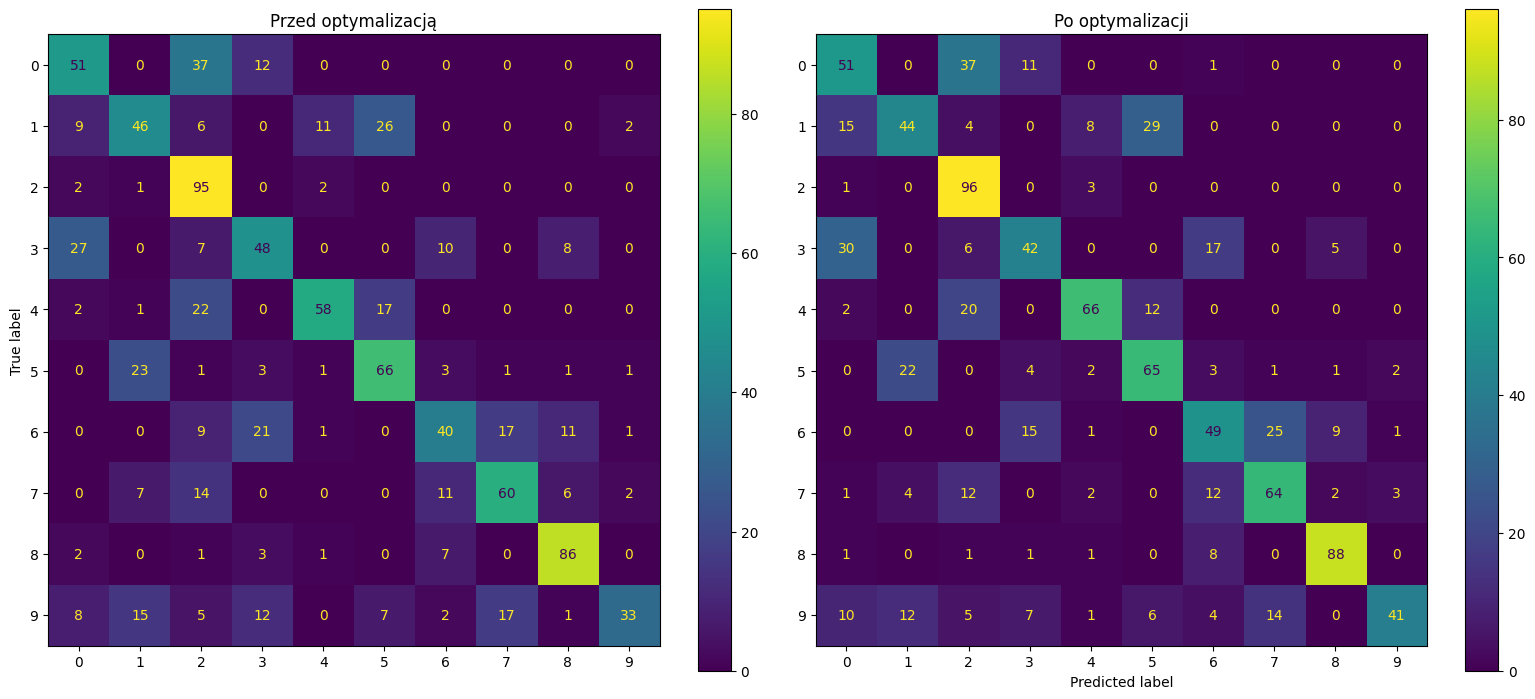

Przed optymalizacja - ACC: 0.583000, F1: 0.574421
Przed optymalizacja - ACC: 0.606000, F1: 0.599643


In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

best_result_preop = all_results[3]
cm_pre_data = best_result_preop["Conf_matrix"]

disp_pre = ConfusionMatrixDisplay(confusion_matrix=cm_pre_data)
disp_pre.plot(ax=axes[0])
axes[0].set_title('Przed optymalizacją')

disp_op = ConfusionMatrixDisplay(confusion_matrix=cm)
disp_op.plot(ax=axes[1])
axes[1].set_title('Po optymalizacji')
axes[1].set_ylabel('')
axes[0].set_xlabel('')

plt.tight_layout()
plt.show()

print(f"Przed optymalizacja - ACC: {best_result_preop['Accuracy']:4f}, F1: {best_result_preop['F1-Score']:4f}")
print(f"Przed optymalizacja - ACC: {acc:4f}, F1: {f1:4f}")

In [33]:
best_lgbm.get_params()

{'boosting_type': 'gbdt',
 'class_weight': None,
 'colsample_bytree': 0.6674934896895227,
 'importance_type': 'split',
 'learning_rate': 0.027298965228939053,
 'max_depth': -1,
 'min_child_samples': 22,
 'min_child_weight': 0.001,
 'min_split_gain': 0.0,
 'n_estimators': 548,
 'n_jobs': 1,
 'num_leaves': 65,
 'objective': 'multiclass',
 'random_state': 42,
 'reg_alpha': 1.319020261299479e-06,
 'reg_lambda': 2.343505742824263e-05,
 'subsample': 0.6274404024478005,
 'subsample_for_bin': 200000,
 'subsample_freq': 0,
 'verbosity': -1}

Tabela z najlepszymi parametrami wygląda następująco:

| Parametr | Wartość |
| :--- | :--- | 
| n_estimators | 548 |
| learning_rate | 0.0273 |
| num_leaves | 65 |
| max_depth | -1 |
| min_child_samples | 22 |
| subsample | 0.6274 |
| colsample_bytree | 0.6675 |
| reg_alpha | 1.32e-06 |
| reg_lambda | 2.34e-05 |

Optymalizacja pozwoliła poprawić metryke ACC i AUC o ponad 2 punkty procentowe, jednak nadal jest to zbyt niski wynik aby model mógł być używany produkcyjnie. Lepsze wyniki można by osiągnąć trenując model na większym zbiorze danych, obejmującym szerszą gamę barw i typów głosów, lub wykorzystując bardziej złożone sieci neuronowe.
